# 01 · Data Ingestion & Cleaning
**Dataset**: [UCI Online Retail II](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)  
**Records**: ~1 million transactions · 8 columns · Dec 2009 – Dec 2011  
**Goal**: Produce a clean, analysis-ready transaction table saved to `data/processed/`

---
## Business Context
A UK-based online gift retailer needs to understand customer behaviour.  
Before any modelling we must trust the data — this notebook handles every  
quality issue in the raw export from their e-commerce system.


## 1. Imports & paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

RAW_PATH  = Path('../data/raw/online_retail.xlsx')
PROC_DIR  = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR  = Path('../docs/eda_plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Paths ready ✓')


Paths ready ✓


## 2. Load raw data
> **Download**: `kaggle datasets download -d mashlyn/online-retail-ii-uci -p data/raw/`  
> A synthetic 50 k-row fallback is generated automatically if the file is absent.

In [2]:
if RAW_PATH.exists():
    df_raw = pd.read_excel(RAW_PATH, engine='openpyxl')
    print(f'Real dataset loaded: {df_raw.shape}')
else:
    # ── synthetic fallback (same schema as real dataset) ──────────────
    rng = np.random.default_rng(42)
    n   = 50_000
    customer_ids = rng.integers(10_000, 18_000, size=4_000)
    qtys         = rng.integers(1, 120, size=n)
    cancel_mask  = rng.random(n) < 0.02
    qtys[cancel_mask] *= -1
    missing_mask = rng.random(n) < 0.05
    dates        = pd.date_range('2010-12-01', '2011-12-09', freq='h')

    df_raw = pd.DataFrame({
        'InvoiceNo':   [f'C{rng.integers(4e5,6e5):.0f}' if q < 0 else str(rng.integers(4e5,6e5))[:-2]
                        for q in qtys],
        'StockCode':   [str(rng.integers(10_000, 99_999)) for _ in range(n)],
        'Description': [f'Product {rng.integers(10_000,99_999)}' for _ in range(n)],
        'Quantity':    qtys,
        'InvoiceDate': rng.choice(dates, n),
        'UnitPrice':   np.round(rng.uniform(0.50, 50.0, n), 2),
        'CustomerID':  [np.nan if m else float(rng.choice(customer_ids)) for m in missing_mask],
        'Country':     rng.choice(
            ['United Kingdom','Germany','France','Spain','Netherlands',
             'Belgium','Switzerland','Portugal','Australia','EIRE'],
            n, p=[0.91,0.02,0.02,0.01,0.01,0.005,0.005,0.005,0.005,0.01]),
    })
    # inject outliers
    oi = rng.choice(n, 20, replace=False)
    df_raw.loc[oi, 'Quantity'] = rng.integers(5_000, 80_000, 20)
    df_raw.loc[oi[:10], 'UnitPrice'] = rng.uniform(500, 2_000, 10)
    print(f'Synthetic fallback generated: {df_raw.shape}')

df_raw.head(3)


Synthetic fallback generated: (50000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,4977,57391,Product 52663,38,2011-05-04 05:00:00,18.95,"10,858.00",United Kingdom
1,5376,68474,Product 45775,101,2011-11-01 05:00:00,7.51,NaN,United Kingdom
2,5717,35553,Product 78376,5,2011-01-07 22:00:00,27.51,"12,180.00",Portugal


## 3. Data quality audit

In [3]:
print('=== Schema ===')
print(df_raw.dtypes)
print(f'\nShape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')

print('\n=== Missing values ===')
miss = df_raw.isnull().sum()
print(miss[miss > 0].to_string())

print('\n=== Descriptive stats (numeric) ===')
df_raw[['Quantity','UnitPrice']].describe().round(2)


=== Schema ===
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Shape: 50,000 rows × 8 cols

=== Missing values ===
CustomerID    2500

=== Descriptive stats (numeric) ===


,Quantity,UnitPrice
count,"50,000.00","50,000.00"
mean,75.09,25.55
std,955.40,27.76
min,-119.00,0.50
25%,28.00,12.68
50%,59.00,25.20
75%,89.00,37.65
max,"76,771.00","1,995.01"


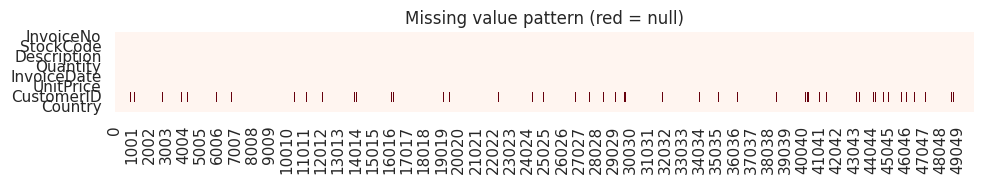

In [4]:
# Visual: missing-value heatmap
fig, ax = plt.subplots(figsize=(10, 2))
sns.heatmap(df_raw.isnull().T, cbar=False, ax=ax, cmap='Reds')
ax.set_title('Missing value pattern (red = null)', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / '00_missing_values.png', dpi=150)
plt.show()


## 4. Step-by-step cleaning
Each step is explicit so you can inspect before/after row counts.

In [5]:
df = df_raw.copy()
print(f'Start: {len(df):,} rows')

# 4a – strip whitespace
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()
print('4a whitespace stripped ✓')

# 4b – drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f'4b duplicates removed: {before - len(df):,}')

# 4c – drop rows with no CustomerID (un-attributable)
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f'4c missing CustomerID dropped: {before - len(df):,}')

# 4d – remove cancelled invoices (InvoiceNo starts with 'C')
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'4d cancelled invoices removed: {before - len(df):,}')

# 4e – remove invalid quantities & prices
before = len(df)
df = df[(df['Quantity'] >= 1) & (df['UnitPrice'] >= 0.01)]
print(f'4e invalid qty/price removed: {before - len(df):,}')

# 4f – remove known non-product stock codes
bad_codes = {'POST', 'D', 'DOT', 'M', 'BANK CHARGES', 'PADS', 'S', 'AMAZONFEE'}
before = len(df)
df = df[~df['StockCode'].str.upper().isin(bad_codes)]
print(f'4f non-product SKUs removed: {before - len(df):,}')

# 4g – outlier capping (Winsorisation at 99th percentile × 3 IQR)
for col in ['Quantity', 'UnitPrice']:
    q99 = df[col].quantile(0.99)
    q01 = df[col].quantile(0.01)
    cap = q99 + 3 * (q99 - q01)
    n_capped = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    print(f'4g [{col}] {n_capped:,} outliers capped at {cap:.1f}')

# 4h – parse dates; extract temporal features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID']  = df['CustomerID'].astype(int)
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['DayOfWeek']   = df['InvoiceDate'].dt.day_name()
df['Hour']        = df['InvoiceDate'].dt.hour
df['IsWeekend']   = df['InvoiceDate'].dt.weekday >= 5

# 4i – derived revenue column
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

print(f'\nFinal clean shape: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Unique customers : {df.CustomerID.nunique():,}')
print(f'Date range       : {df.InvoiceDate.min().date()} → {df.InvoiceDate.max().date()}')


Start: 50,000 rows
4a whitespace stripped ✓
4b duplicates removed: 0
4c missing CustomerID dropped: 2,500
4d cancelled invoices removed: 912
4e invalid qty/price removed: 0
4f non-product SKUs removed: 0
4g [Quantity] 19 outliers capped at 466.0
4g [UnitPrice] 9 outliers capped at 195.1



Final clean shape: 46,588 rows × 14 cols
Unique customers : 3,155
Date range       : 2010-12-01 → 2011-12-09


## 5. Post-cleaning validation

In [6]:
checks = {
    'No null CustomerID'     : df['CustomerID'].isna().sum() == 0,
    'No cancelled invoices'  : (~df['InvoiceNo'].astype(str).str.startswith('C')).all(),
    'All quantities >= 1'    : (df['Quantity'] >= 1).all(),
    'All prices >= 0.01'     : (df['UnitPrice'] >= 0.01).all(),
    'TotalRevenue > 0'       : (df['TotalRevenue'] > 0).all(),
    'InvoiceDate is datetime': pd.api.types.is_datetime64_any_dtype(df['InvoiceDate']),
}
for check, result in checks.items():
    status = '✅' if result else '❌'
    print(f'{status}  {check}')


✅  No null CustomerID
✅  No cancelled invoices
✅  All quantities >= 1
✅  All prices >= 0.01
✅  TotalRevenue > 0
✅  InvoiceDate is datetime


## 6. Save cleaned data

In [7]:
df.to_csv( PROC_DIR / 'online_retail_clean.csv',     index=False)
df.to_parquet(PROC_DIR / 'online_retail_clean.parquet', index=False)

print('Saved:')
print(f'  {PROC_DIR}/online_retail_clean.csv')
print(f'  {PROC_DIR}/online_retail_clean.parquet')
print(f'\nRows: {len(df):,} | Customers: {df.CustomerID.nunique():,}')
df.head(3)


Saved:
  ../data/processed/online_retail_clean.csv
  ../data/processed/online_retail_clean.parquet

Rows: 46,588 | Customers: 3,155


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,DayOfWeek,Hour,IsWeekend,TotalRevenue
0,4977,57391,Product 52663,38,2011-05-04 05:00:00,18.95,10858,United Kingdom,2011,5,Wednesday,5,False,720.10
2,5717,35553,Product 78376,5,2011-01-07 22:00:00,27.51,12180,Portugal,2011,1,Friday,22,False,137.55
3,4027,58424,Product 78985,54,2010-12-13 23:00:00,2.66,14117,United Kingdom,2010,12,Monday,23,False,143.64
